# 04 - Decision-focused learning (DFL) on the simulated panel

The DFL model of the methodology chapter (S3.2.4): the interpretable PD forecast is kept,
`pd_hat_{t+1} = f_theta(x_t)` (eq. 3.49), but trained end-to-end on decision regret
(eq. 3.33) through a differentiable allocation layer `alpha*(pd_hat)` (eq. 3.50).

This notebook is scoped to DFL only: it trains and evaluates `dfl_linear` / `dfl_mlp`
against the foresight oracle and Bayes oracle already stored in the simulated panel
(`01_simulate_pd_panel`), on the same expanding-window protocol used everywhere else in
this project. It does not re-run PTO, does not compute persistence baselines, and does
not run Diebold-Mariano tests or any cross-notebook comparison against PTO or the black
box - those live in a separate cross-model comparison notebook that reads the per-model
result CSVs each model notebook saves (`dfl_sim_predictions_main.csv` here, alongside
`pto_sim_predictions_main.csv` from 02 and `blackbox_sim_predictions_main.csv` from 03).

**The allocation layer.** The forward decision solves the smooth forecast-based objective
(eq. 3.24/3.25) - expected terminal capital minus the lambda-weighted Vasicek expected
shortfall penalty - continuously by **bisection on the first-order condition** F = 0.
The backward pass never differentiates through the solver: by the **implicit function
theorem** on the FOC,

    dalpha*/dpd = - (dF/dpd) / (dF/dalpha) |_(alpha*),

with both partials in closed form (dF/dalpha = -lambda f_L(x) / (ell alpha^3 LGD) < 0 by
strict concavity, so the ratio is well defined at any interior optimum; boundary optima
get an exactly-zero gradient). A grid argmax would make alpha*(pd) a step function with
zero gradient almost everywhere and DFL would silently fail to train - the continuous
solve is what makes the method possible, in training AND at evaluation (there is no grid
snap anywhere in this notebook, matching 01/02/03). Full DFL chain rule (eq. 3.52):
realised regret subgradient (torch, eq. 3.43) x IFT ratio (custom backward) x network
Jacobian (autodiff).

Shared with the rest of the project (fairness rule): features and timing, per-window
scaler, expanding windows with `REFIT_EVERY`, the continuous alpha optimiser and utility
constants, realised evaluation at `K_IRB_true_{t+1}`, the two-oracle regret decomposition,
and architecture capacity/hyperparameter budget (identical linear and MLP bodies with a
sigmoid head, eq. 3.30-3.31, output read as PD). Training signal is the same hindsight
information as the black box (realised `c_{t+1}`, `K_IRB_true_{t+1}`, foresight-oracle
utility) - DFL just routes it through a PD intermediate and the implicit layer instead of
directly to an allocation.

Different by design vs both benchmarks: unlike PTO the forecast is trained on the
downstream objective; unlike the black box the PD intermediate survives, so **all PD
accuracy/calibration diagnostics apply to DFL** - the auditability comparison of the
thesis. Documented gradient simplification: the Vasicek/IRB correlation rho = R(pd_a)
is held FIXED when differentiating (the correlation channel R'(pd) is omitted from the
gradient; the forward pass always evaluates the exact rho). The gradient-audit cell
quantifies the omitted channel against a full finite difference.


In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.special import ndtri, owens_t
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the DFL policy/forecast networks. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "simulation" / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS

PANEL_CSV = ROOT / "simulation" / "data" / "simulated_pd_panel.csv"
METADATA_PATH = ROOT / "simulation" / "data" / "simulated_pd_panel_metadata.json"
FIGURES_DIR = ROOT / "simulation" / "figures" / "04_dfl_pd_irb_sim"
RESULTS_DIR = ROOT / "simulation" / "results" / "04_dfl"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Panel: {PANEL_CSV.relative_to(ROOT)}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")


Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Panel: simulation/data/simulated_pd_panel.csv
Figures: simulation/figures/04_dfl_pd_irb_sim
Results: simulation/results/04_dfl


## Configuration

Decision and Basel constants are read from the simulator's metadata JSON so this
notebook cannot silently diverge from `01_simulate_pd_panel` / `02_pto_simulated_panel`;
the asserts below fail loudly if the panel was built with different constants than
expected.

The simulated panel is long (~1000 quarters), so refitting every window is unnecessary
and slow. `REFIT_EVERY = 8` refits the scaler and the DFL networks every 8th test quarter
and reuses them in between (predictions are still one-step-ahead and use only past data).
`DFL_SEEDS` / `DFL_MODEL_CFG` pin DFL to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP in 02 (fairness rule), even
though PTO itself is not re-run here.


In [9]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from the simulator, asserted rather than assumed)
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST.get("APPLY_PD_FLOOR", True))
PD_FLOOR = float(CONST.get("PD_FLOOR", 3e-4))
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99

# Allocation decisions are optimised continuously on [0, 1] (a bounded scalar solver for
# the recomputed oracle; bisection on the FOC for DFL's own decision) rather than snapped
# to a discrete grid, matching 01_simulate_pd_panel and 02_pto_simulated_panel.
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = float(CONST.get("alpha_opt_xatol", 1e-10))

# Data conventions
HORIZON = 1
DATE_COL = "date"
FEATURE_COLS = list(META["feature_cols"])
REFIT_EVERY = 8                 # 1 = strict every-window refits
RHO_SCALE = float(CONST.get("RHO_SCALE", 1.0))

EVAL_SPLITS = {
    "main": {"initial_train_frac": 0.7},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 200
    patience: int = 30
    val_frac: float = 0.2
    seed: int = 42

DFL_MODEL_CFG = ModelConfig()
DFL_SEEDS = (42, 43, 44, 45, 46)

# DFL's own implicit-allocation-layer solver settings (bisection forward, IFT backward).
DFL_ALPHA_LO = 1e-4             # lower bisection bracket (alpha* = 0 handled as boundary)
DFL_BISECT_ITERS = 30           # bracket halves 60x: alpha* to ~1e-18, far tighter than any grid
DFL_FD_REL = 1e-5               # relative step for the K'_IRB central finite difference
DFL_GRAD_CLIP = 1e3             # safety clamp on |dalpha*/dpd| (thresholds near support edge)

print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}, "
      f"PD floor={PD_FLOOR} (applied={APPLY_PD_FLOOR})")
print(f"Features: {FEATURE_COLS}")
print(f"DFL: PD forecaster trained on realised regret through the implicit allocation layer "
      f"(bisection + IFT); seeds {DFL_SEEDS}; rho held fixed in the gradient.")


Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0, PD floor=0.0003 (applied=True)
Features: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']
DFL: PD forecaster trained on realised regret through the implicit allocation layer (bisection + IFT); seeds (42, 43, 44, 45, 46); rho held fixed in the gradient.


## Assumptions and caveats

- **Same decision problem as the simulator**: linear shortfall penalty, and committed
  capital excluded from the available buffer (equivalent to a fixed management buffer
  add-on of `1/LEVERAGE` per unit exposure - intentional, it makes the constraint bind
  in the interior of alpha in [0, 1]).
- **Realised utility uses the true capital requirement** `K_IRB_true_{t+1}` from the
  panel, matching the simulator's oracle convention. DFL still acts on its own
  `k_irb(pd_a_hat)` inside the allocation layer, so capital misestimation affects the
  decision, but the evaluation is against the true requirement.
- **PD bias initialisation uses the realised implied PD** `c_{t+1}/LGD` (unbiased for
  true PD, but carries Vasicek noise) for the output-bias warm start only - DFL's
  training loss itself is realised regret, not a PD loss, so this target never touches
  the gradient.
- **No reporting lag**: `c_t` is observable at decision time by construction (stated in
  the simulator's metadata).
- **Constant LGD, constant yield, corporate IRB curve**: inherited from the simulator by
  design so that synthetic and empirical results are comparable.
- **DFL training signal is hindsight-outcome information only**: per training sample it
  uses realised `c_{t+1}`, the true capital requirement `K_IRB_true_{t+1}`, and the
  foresight-oracle utility as training TARGETS only - the same information status as the
  black-box benchmark. Input features are exactly `feature_cols`; nothing from the
  panel's diagnostic-only columns is ever an input.
- **DFL decides through the smooth expected-utility objective, solved continuously by
  bisection on the FOC (eq. 3.24-3.25), with the gradient supplied by the implicit
  function theorem** - not by differentiating through the solver. This is not an
  evaluation convenience but a training necessity: a grid argmax would make alpha*(pd)
  a step function with zero gradient almost everywhere, and DFL could not train at all.
- **Correlation channel omitted from the gradient**: rho = R(pd_a) is held fixed at its
  evaluated value when differentiating (forward pass exact; audited below against a
  full finite difference). `K'_IRB` is evaluated by central finite difference on the
  composite quarterly -> annualised -> Basel map (annualisation chain included).


## PD conversions, Basel IRB, and allocation objective

Identical formulas to the empirical notebook and to `01_simulate_pd_panel` /
`02_pto_simulated_panel`. The allocation utility takes the capital requirement `k`
directly (the panel supplies `K_IRB_true` for evaluation; DFL computes
`k_irb_from_annual_pd(pd_a_hat)` for its own decision). `optimise_alpha_oracle` is the
continuous-optimum solver used only to recompute the foresight oracle here as a
cross-notebook consistency check against the panel's stored oracle - DFL's own decision
never calls it (that goes through the implicit allocation layer below).


In [10]:
def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    # U(alpha; c_q, k). Buffer semantics are intentional: committed capital alpha*k1 is
    # excluded from the buffer, equivalent to a 1/leverage management buffer add-on.
    alpha = np.asarray(alpha, dtype=float)
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - float(c_q))
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, k):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=float(k))


def optimise_alpha_oracle(c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    """Continuous-optimum allocation for one point estimate (c_q, k) (Brent's method via
    scipy.optimize.minimize_scalar, both domain boundaries checked explicitly). Identical
    objective, solver and tolerance to the equivalent function in 01_simulate_pd_panel /
    02_pto_simulated_panel / 03_blackbox_simulated_panel - see the cross-notebook
    consistency check below."""
    def neg_utility(alpha):
        return -float(allocation_utility(alpha, c_q=c_q, k=k, leverage=leverage, y_bar=y_bar,
                                          lambda_penalty=lambda_penalty, k1=k1))

    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                           options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    return max(candidates, key=lambda item: item[1])


## Load and align the simulated panel

The forecasting row is `x_t -> quarter t+1`. Targets and evaluation columns are the
next-quarter values; `_true` columns are for evaluation and the oracle benchmarks only
and are asserted never to appear among the features. `target_pd_q_next` (the realised
implied PD `c_{t+1}/LGD`) is used only to initialise DFL's output bias - not as a
training loss, since DFL trains on realised regret through the implicit allocation layer.


In [11]:
def load_simulated_panel(panel_csv, feature_cols, horizon=HORIZON):
    df = pd.read_csv(panel_csv)
    df[DATE_COL] = pd.PeriodIndex(df[DATE_COL], freq="Q").to_timestamp()
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Panel is missing feature columns: {missing}")

    # Next-quarter outcomes for target construction and decision evaluation.
    df["target_date"] = df[DATE_COL].shift(-horizon)
    df["c_q_realised"] = df["c"].shift(-horizon)
    df["pd_q_realised"] = clip_pd_q(df["c_q_realised"] / LGD)
    df["pd_q_true_next"] = df["PD_quarterly_true"].shift(-horizon)
    df["pd_a_true_next"] = df["PD_annual_true"].shift(-horizon)
    df["k_irb_true_next"] = df["K_IRB_true"].shift(-horizon)
    df["alpha_oracle_next"] = df["alpha_oracle"].shift(-horizon)
    df["utility_oracle_next"] = df["utility_oracle"].shift(-horizon)
    df["alpha_bayes_next"] = df["alpha_bayes"].shift(-horizon)
    df["utility_bayes_realised_next"] = df["utility_bayes_realised"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    required = list(feature_cols) + ["target_date", "c_q_realised", "pd_q_realised", "pd_q_true_next",
                                     "pd_a_true_next", "k_irb_true_next", "alpha_oracle_next",
                                     "utility_oracle_next", "alpha_bayes_next",
                                     "utility_bayes_realised_next", "target_pd_q_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 100:
        raise ValueError(f"Only {len(df)} usable observations; check the panel.")
    return df

df = load_simulated_panel(PANEL_CSV, FEATURE_COLS)

forbidden = {"PD_quarterly_true", "PD_annual_true", "PD_true", "expected_c_quarterly", "K_IRB_true",
             "alpha_oracle", "alpha_bayes", "latent_state", "latent_cycle"}
assert not (forbidden & set(FEATURE_COLS)), "True/diagnostic columns leaked into features."
assert "c" in FEATURE_COLS and "c_lag1" in FEATURE_COLS
print(f"Observations after alignment: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
display(df[[DATE_COL] + FEATURE_COLS + ["target_pd_q_next", "pd_q_true_next"]].head())


Observations after alignment: 998
Feature date range: 1980-04-01 to 2229-07-01


,date,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth,c,c_lag1,target_pd_q_next,pd_q_true_next
0,1980-04-01,-0.203143,0.897137,-0.055082,-0.208364,0.273917,0.002093,0.001309,0.005557,0.006202
1,1980-07-01,-0.833491,0.699530,0.607612,-0.173439,-0.690280,0.002501,0.002093,0.002236,0.003253
2,1980-10-01,-0.608899,-0.001785,0.141476,0.415671,-0.206404,0.001006,0.002501,0.002611,0.003445
3,1981-01-01,-1.143365,-0.339549,0.567634,-0.941497,0.366174,0.001175,0.001006,0.002822,0.003464
4,1981-04-01,0.126592,-0.095532,-0.437445,0.586255,0.399816,0.001270,0.001175,0.005042,0.004704


## DFL forecaster architecture

Identical PD-forecaster architecture used across the project (raw-score output whose
sigmoid is the predicted quarterly PD, bias initialised from the pre-validation slice,
chronological train/validation split with shuffled mini-batches, early stopping, MLP
seed ensemble) - only the loss differs from a PTO predictor: DFL trains on realised
regret through the implicit allocation layer defined in the next section, not on a PD
prediction loss.


In [12]:
def clip_pd_q_t(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score). Same linear /
    # two-hidden-layer MLP bodies used for the PTO forecaster in 02_pto_simulated_panel
    # (fairness rule: identical architecture and capacity).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q_t(np.atleast_1d(pred))


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)


## DFL core: smooth objective, bisection forward pass, IFT backward pass

- `dfl_smooth_utility` / `dfl_foc`: the forecast-based objective U_hat(alpha; pd) (thesis
  eq. 3.24) and its first-order condition F = dU_hat/dalpha, in closed form via the
  Vasicek expected shortfall ES = Phi2(ndtri(pd), y_x; sqrt(rho)) - x Phi(y_x)
  (eq. 3.26-3.28; `bvn_cdf` is the same Owen's-T bivariate normal CDF used in
  `01_simulate_pd_panel` / `02_pto_simulated_panel` / `03_blackbox_simulated_panel` - one
  implementation everywhere. The hand-derived IFT gradient below never differentiates
  through this function: dF/dpd is built entirely from univariate Phi/phi terms (the
  bivariate-CDF term appears only in the forward FOC value F itself, and cancels out of
  the gradient identically), so the choice of bivariate-CDF implementation only affects
  the precision of the forward bisection, never the gradient's correctness);
- `solve_alpha_star`: vectorised bisection on F = 0. F is strictly decreasing wherever
  the Vasicek density at the threshold is positive (d2U/dalpha2 =
  -lambda f_L(x) / (ell alpha^3 LGD) < 0), so endpoint sign checks detect boundary
  optima (F(1) >= 0 -> alpha* = 1; F(lo) <= 0 -> alpha* = 0) and bisection converges to
  the unique interior root otherwise. The same call returns the closed-form IFT
  gradient dalpha*/dpd (zero at boundaries), assembled from: the threshold channel
  via K'_IRB (central finite difference on the composite quarterly -> annualised ->
  Basel map, annualisation chain 4(1-pd)^3 included), the distribution-mean channel
  via Psi = Phi((y_x - sqrt(rho) ndtri(pd)) / sqrt(1-rho)) and the exceedance-density
  term, with rho held fixed (documented simplification);
- `ImplicitAllocation`: the torch autograd wrapper - non-differentiable bisection in
  forward, the IFT ratio in backward;
- `train_dfl_model` / `train_dfl_ensemble`: identical mechanics to a regret-training loop
  (chronological validation split, shuffled mini-batches, early stopping on validation
  regret, same ModelConfig and seed ensemble), with the network output read as a PD
  forecast and passed through the implicit layer. Validation-window PD RMSE/MAE against
  the realised implied PD are tracked every epoch alongside regret (DFL produces a PD
  every epoch regardless of what it is trained on, so this diagnostic is free) - this is
  what lets the learning-curve and calibration plots below show DFL's PD accuracy even
  though PD accuracy is not what DFL optimises.

There is no grid snap anywhere - the continuous bisection optimum is used directly both
during training (where it must be, for the gradient to exist) and at evaluation.


In [13]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable realised utility - same constants and the same intentional buffer
    semantics as allocation_utility (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it
    (thesis eq. 3.43: the realised regret subgradient shared with the black-box benchmark)."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


# ---------------------------------------------------------------------------------------
# DFL core: smooth forecast-based objective, bisection forward pass, IFT backward pass.
#
# Forward decision map (thesis eq. 3.24/3.25): given the model\'s own quarterly PD forecast,
#   alpha*(pd_q) = argmax_alpha  1 + ell*alpha*(y_bar - LGD*pd_q)
#                              - lambda*ell*alpha*LGD * E[(L - x(alpha, pd_q))^+]
# with L ~ Vasicek(pd_q, rho), rho = DFL_RHO_SCALE * BaselR(pd_a(pd_q)) (matching the
# simulator convention), and threshold
#   x(alpha, pd_q) = ((1 - alpha) + ell*alpha*(y_bar - k)) / (ell*alpha*LGD),
#   k = K_IRB(pd_a(pd_q)).
# The optimum solves the FOC F(alpha, pd_q) = 0 with
#   F = ell*(y_bar - LGD*pd_q) - lambda*ell*LGD*ES(x; pd_q, rho) - (lambda/alpha)*P(L > x).
# F is strictly decreasing where the Vasicek density at the threshold is positive
# (d2U/dalpha2 = -lambda * f_L(x) / (ell * alpha^3 * LGD) < 0), so a sign check at the
# brackets detects boundary solutions and bisection finds the unique interior root.
#
# Backward pass (implicit function theorem on the FOC):
#   dalpha*/dpd = - (dF/dpd) / (dF/dalpha) |_(alpha*)     [zero at boundary solutions]
#   dF/dalpha = -lambda * f_L(x) / (ell * alpha^3 * LGD)
#   dF/dpd    = -ell*LGD - lambda*ell*LGD*( P(L>x)*Kp/LGD + Psi )
#               - (lambda/alpha)*( f_L(x)*Kp/LGD + phi(y_x)/(sqrt(rho)*phi(ndtri(pd))) )
# where Kp = d K_IRB(pd_a(pd_q)) / d pd_q (central finite difference on the composite
# quarterly -> annual -> Basel map), and
#   Psi = Phi( (y_x - sqrt(rho)*ndtri(pd)) / sqrt(1-rho) )  in (0,1)
# is dES/dpd at fixed threshold (the y_x-channel terms cancel identically).
# Simplification (documented in the thesis): rho is held fixed at its evaluated value
# when differentiating; the correlation channel R\'(pd) is omitted from the gradient.
# The forward pass always evaluates the exact rho.
# ---------------------------------------------------------------------------------------
DFL_RHO_SCALE = RHO_SCALE
_X_EPS = 1e-9          # threshold considered outside (0,1) beyond this
_PD_LO, _PD_HI = PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH


def dfl_basel_r_annual(pd_a):
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    return 0.12 * exp_term + 0.24 * (1.0 - exp_term)


def dfl_rho(pd_a):
    return np.clip(DFL_RHO_SCALE * dfl_basel_r_annual(pd_a), 1e-4, 0.999)


def bvn_cdf(a, b, r):
    """Bivariate standard normal CDF Phi2(a, b; r), vectorised, elementwise r, via
    Owen's T function (Owen, 1956) - identical implementation to
    bivariate_normal_cdf in 01_simulate_pd_panel / 02_pto_simulated_panel /
    03_blackbox_simulated_panel, so every notebook uses one bivariate-CDF machinery.
    Phi2(h, k; rho) = 1/2*(Phi(h) + Phi(k)) - T(h, a) - T(k, b) - delta, with
    a = (k/h - rho) / sqrt(1 - rho^2), b = (h/k - rho) / sqrt(1 - rho^2), and
    delta = 0 if h*k > 0 (or h*k == 0 and h + k >= 0), else 1/2. This function is only
    ever used for the forward FOC value (see the gradient-audit note above); the IFT
    gradient does not call it."""
    h = np.atleast_1d(np.asarray(a, dtype=float))
    k = np.atleast_1d(np.asarray(b, dtype=float))
    rho = np.clip(np.atleast_1d(np.asarray(r, dtype=float)), -0.999999, 0.999999)
    denom = np.sqrt(np.maximum(1.0 - rho ** 2, 1e-300))
    h_safe = np.where(h == 0.0, 1e-12, h)
    k_safe = np.where(k == 0.0, 1e-12, k)
    aa = (k / h_safe - rho) / denom
    bb = (h / k_safe - rho) / denom
    val = 0.5 * (norm.cdf(h) + norm.cdf(k)) - owens_t(h_safe, aa) - owens_t(k_safe, bb)
    hk = h * k
    delta = np.where((hk > 0.0) | ((hk == 0.0) & (h + k >= 0.0)), 0.0, 0.5)
    return val - delta


def dfl_threshold_x(alpha, k):
    return ((1.0 - alpha) + LEVERAGE * alpha * (Y_BAR - k)) / (LEVERAGE * alpha * LGD)


def vasicek_es_exceed(x, pd_q, rho):
    """Closed-form E[(L-x)^+] and P(L > x) under Vasicek(pd_q, rho); handles thresholds
    outside (0,1): x <= 0 -> hinge always active (ES = pd - x, P = 1); x >= 1 -> never
    active (ES = 0, P = 0). Returns (ES, P, y_x, inside_mask)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    a = ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    y_x = (a - np.sqrt(1.0 - rho) * ndtri(x_in)) / np.sqrt(rho)
    p_in = norm.cdf(y_x)
    es_in = bvn_cdf(a, y_x, np.sqrt(rho)) - x_in * p_in
    es = np.where(inside, es_in, np.where(x <= _X_EPS, pd_q - x, 0.0))
    p = np.where(inside, p_in, np.where(x <= _X_EPS, 1.0, 0.0))
    return es, p, y_x, inside


def vasicek_pdf(x, pd_q, rho):
    """Vasicek default-rate density f_L(x; pd_q, rho) (thesis eq. 3.7); 0 outside (0,1)."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    pd_q = np.atleast_1d(np.asarray(pd_q, dtype=float))
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    inside = (x > _X_EPS) & (x < 1.0 - _X_EPS)
    x_in = np.clip(x, _X_EPS, 1.0 - _X_EPS)
    a = ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    xi = ndtri(x_in)
    dens = (np.sqrt((1.0 - rho) / rho)
            * np.exp(-((np.sqrt(1.0 - rho) * xi - a) ** 2) / (2.0 * rho) + 0.5 * xi ** 2))
    return np.where(inside, dens, 0.0)


def dfl_smooth_utility(alpha, pd_q, k, rho):
    """Forecast-based expected utility U_hat(alpha; pd_q) (thesis eq. 3.24), closed form."""
    x = dfl_threshold_x(alpha, k)
    es, _, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (K1 + LEVERAGE * alpha * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * alpha * LGD * es)


def dfl_foc(alpha, pd_q, k, rho):
    """F(alpha, pd_q) = dU_hat/dalpha."""
    x = dfl_threshold_x(alpha, k)
    es, p, _, _ = vasicek_es_exceed(x, pd_q, rho)
    return (LEVERAGE * (Y_BAR - LGD * pd_q)
            - LAMBDA * LEVERAGE * LGD * es - (LAMBDA / alpha) * p)


def dfl_context(pd_q):
    """Per-sample constants: annual PD, K_IRB, rho, and the composite derivative
    Kp = dK_IRB(pd_a(pd_q))/dpd_q by central finite difference (annualisation chain
    4(1-pd_q)^3 included automatically by differencing the composite map)."""
    pd_q = clip_pd_q(pd_q)
    pd_a = quarterly_pd_to_annual(pd_q)
    k = k_irb_from_annual_pd(pd_a)
    rho = dfl_rho(pd_a)
    h = np.maximum(1e-8, DFL_FD_REL * pd_q)
    k_up = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q + h))
    k_dn = k_irb_from_annual_pd(quarterly_pd_to_annual(pd_q - h))
    kp = (k_up - k_dn) / (2.0 * h)
    return pd_a, k, rho, kp


def solve_alpha_star(pd_q):
    """Vectorised forward + backward pass of the implicit allocation layer.
    Returns (alpha_star, dalpha_dpd). Boundary solutions get zero gradient.
    F is strictly decreasing in alpha wherever f_L(x) > 0 (strict concavity of U_hat),
    so: F(lo) <= 0 -> alpha* = 0; F(1) >= 0 -> alpha* = 1; else bisection on the
    unique interior root."""
    pd_q = clip_pd_q(np.atleast_1d(np.asarray(pd_q, dtype=float)))
    n = pd_q.shape[0]
    _, k, rho, kp = dfl_context(pd_q)

    lo = np.full(n, DFL_ALPHA_LO)
    hi = np.ones(n)
    f_lo = dfl_foc(lo, pd_q, k, rho)
    f_hi = dfl_foc(hi, pd_q, k, rho)
    at_one = f_hi >= 0.0
    at_zero = (~at_one) & (f_lo <= 0.0)
    interior = ~(at_one | at_zero)

    a_lo, a_hi = lo.copy(), hi.copy()
    for _ in range(DFL_BISECT_ITERS):
        mid = 0.5 * (a_lo + a_hi)
        f_mid = dfl_foc(mid, pd_q, k, rho)
        go_up = f_mid > 0.0
        a_lo = np.where(interior & go_up, mid, a_lo)
        a_hi = np.where(interior & ~go_up, mid, a_hi)
    alpha = np.where(at_one, 1.0, np.where(at_zero, 0.0, 0.5 * (a_lo + a_hi)))

    # IFT gradient at the interior optimum (zero at boundaries).
    a_safe = np.clip(alpha, DFL_ALPHA_LO, 1.0)
    x = dfl_threshold_x(a_safe, k)
    es, p, y_x, inside = vasicek_es_exceed(x, pd_q, rho)
    f_l = vasicek_pdf(x, pd_q, rho)
    a_probit = ndtri(np.clip(pd_q, _PD_LO, 1.0 - _PD_LO))
    psi = np.where(inside, norm.cdf((y_x - np.sqrt(rho) * a_probit) / np.sqrt(1.0 - rho)),
                   np.where(x <= _X_EPS, 1.0, 0.0))
    dF_dalpha = -LAMBDA * f_l / (LEVERAGE * a_safe ** 3 * LGD)
    phi_a = np.maximum(norm.pdf(a_probit), 1e-300)
    dist_term = np.where(inside, norm.pdf(y_x) / (np.sqrt(rho) * phi_a), 0.0)
    dF_dpd = (-LEVERAGE * LGD
              - LAMBDA * LEVERAGE * LGD * (p * kp / LGD + psi)
              - (LAMBDA / a_safe) * (f_l * kp / LGD + dist_term))
    with np.errstate(divide="ignore", invalid="ignore"):
        grad = np.where(interior & (np.abs(dF_dalpha) > 1e-300), -dF_dpd / dF_dalpha, 0.0)
    grad = np.clip(np.nan_to_num(grad, nan=0.0, posinf=0.0, neginf=0.0),
                   -DFL_GRAD_CLIP, DFL_GRAD_CLIP)
    return alpha, grad


class ImplicitAllocation(torch.autograd.Function):
    """Differentiable allocation layer: forward solves the FOC by bisection; backward
    multiplies the incoming gradient by the closed-form IFT ratio dalpha*/dpd. The
    solver is never differentiated through - the gradient exists in closed form, so a
    non-differentiable root-finder in the forward pass is fine."""

    @staticmethod
    def forward(ctx, pd_q_tensor):
        pd_np = pd_q_tensor.detach().cpu().numpy().astype(float).ravel()
        alpha, grad = solve_alpha_star(pd_np)
        ctx.save_for_backward(torch.as_tensor(grad, dtype=pd_q_tensor.dtype))
        return torch.as_tensor(alpha, dtype=pd_q_tensor.dtype).reshape(pd_q_tensor.shape)

    @staticmethod
    def backward(ctx, grad_output):
        (dalpha_dpd,) = ctx.saved_tensors
        return grad_output * dalpha_dpd.reshape(grad_output.shape)


def implicit_alpha(pd_q_tensor):
    return ImplicitAllocation.apply(pd_q_tensor)


def allocation_utility_vec(alpha, c_q, k):
    """Vectorised realised utility over samples (alpha, c, k all 1-D)."""
    alpha = np.asarray(alpha, dtype=float)
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - np.asarray(c_q, dtype=float))
    available_buffer = terminal_capital - alpha * K1
    shortfall = np.maximum(np.asarray(k, dtype=float) * exposure - available_buffer, 0.0)
    return terminal_capital - LAMBDA * shortfall


def train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_type,
                    model_cfg, seed=None, return_history=False):
    """DFL training: PD forecaster trained by minimising mean realised regret
        regret_t = U_oracle(t+1) - U(alpha*(pd_hat_t); c_{t+1}, K_{t+1})
    through the implicit allocation layer (chronological validation split, shuffled
    mini-batches, early stopping on validation regret). Gradient chain (thesis):
    realised-utility subgradient (torch, eq. 3.43) x IFT ratio (custom backward,
    eq. IFT gradient) x network Jacobian (autodiff). y_train_pd_q (the realised implied
    PD) only initialises the output bias and is used to track validation PD RMSE/MAE as
    a free diagnostic each epoch - it never enters the loss."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(arr):
        return torch.tensor(np.asarray(arr, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]
    y_val = y_train_pd_q[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_train_pd_q[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
        alpha = implicit_alpha(pd_q)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            pd_val = torch.sigmoid(score_val).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH).cpu().numpy()
        alpha_val, _ = solve_alpha_star(pd_val)
        val_regret = float(np.mean(u_val - allocation_utility_vec(alpha_val, c_val, k_val)))
        val_rmse_pd_q = float(np.sqrt(mean_squared_error(y_val, pd_val)))
        val_mae_pd_q = float(mean_absolute_error(y_val, pd_val))
        history.append({"epoch": epoch + 1, "model": f"dfl_{model_type}", "seed": seed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": val_regret,
                        "val_rmse_pd_q": val_rmse_pd_q, "val_mae_pd_q": val_mae_pd_q,
                        "val_mean_pd_q_hat": float(np.mean(pd_val)),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {kk: v.detach().clone() for kk, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def train_dfl_ensemble(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, model_cfg,
                       seeds=DFL_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_dfl_model(x_train, y_train_pd_q, c_next, k_next, u_oracle_next, "mlp",
                              model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


## Gradient audit

Every analytic ingredient of the implicit gradient is checked against an independent
numerical reference before any training runs. A wrong gradient here fails silently as
"DFL never beats the other methods", indistinguishable from a genuine null result. The
audit also quantifies the one documented simplification: the gap between the IFT
gradient (rho fixed) and the full finite difference of the solver is exactly the omitted
correlation channel R'(pd), reported per test point for the thesis write-up.


In [14]:
# Gradient audit (run once, before any training). A transcription error in the implicit
# gradient fails silently as a null result, so every analytic ingredient is checked
# against an independent reference here:
#   1. bvn_cdf vs scipy's bivariate normal CDF;
#   2. the FOC F vs a central finite difference of the smooth utility U_hat;
#   3. bisection alpha* vs a fine-grid argmax of U_hat;
#   4. the IFT gradient vs a finite difference of the solver with rho FROZEN (exact
#      match expected), and vs the full finite difference (the gap IS the documented
#      omitted correlation channel R'(pd), reported for the thesis).
from scipy.stats import multivariate_normal as _mvn_audit

audit_pds = np.unique(np.round(np.quantile(
    df["pd_q_realised"].dropna().to_numpy(), [0.05, 0.25, 0.5, 0.75, 0.95]), 6))

print("1) bvn_cdf vs scipy:")
_bvn_err = 0.0
for _a, _b, _r in [(-2.1, 0.5, 0.4), (0.3, -0.6, 0.49), (-1.0, -1.0, 0.35), (1.5, -0.7, 0.45)]:
    _ref = float(_mvn_audit(mean=[0, 0], cov=[[1, _r], [_r, 1]]).cdf([_a, _b]))
    _bvn_err = max(_bvn_err, abs(float(bvn_cdf(_a, _b, _r)[0]) - _ref))
print(f"   max abs err = {_bvn_err:.2e}")
assert _bvn_err < 1e-8

print("2) FOC F vs central FD of U_hat:")
_foc_err = 0.0
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    for _al in [0.05, 0.2, 0.5, 0.9]:
        _h = 1e-6
        _fd = (dfl_smooth_utility(np.array([_al + _h]), np.array([_pd]), _k, _rho)[0]
               - dfl_smooth_utility(np.array([_al - _h]), np.array([_pd]), _k, _rho)[0]) / (2 * _h)
        _an = float(dfl_foc(np.array([_al]), np.array([_pd]), _k, _rho)[0])
        _foc_err = max(_foc_err, abs(_fd - _an) / max(1.0, abs(_an)))
print(f"   max rel err = {_foc_err:.2e}")
assert _foc_err < 1e-4

print("3) bisection alpha* vs fine-grid argmax of U_hat:")
_agrid = np.linspace(DFL_ALPHA_LO, 1.0, 200001)
for _pd in audit_pds:
    _, _k, _rho, _ = dfl_context(np.array([_pd]))
    _ug = dfl_smooth_utility(_agrid, np.full_like(_agrid, _pd),
                             np.full_like(_agrid, _k[0]), np.full_like(_agrid, _rho[0]))
    _ag = float(_agrid[np.argmax(_ug)])
    _ab, _g = solve_alpha_star(np.array([_pd]))
    print(f"   pd={_pd:.5f}  grid={_ag:.5f}  bisect={float(_ab[0]):.5f}  dalpha/dpd={float(_g[0]):+9.3f}")
    assert abs(_ag - float(_ab[0])) < 2e-4 or (_ag >= 1.0 - 1e-4 and float(_ab[0]) == 1.0) \
        or (_ag <= DFL_ALPHA_LO * 2 and float(_ab[0]) == 0.0)

print("4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):")
_orig_dfl_rho = dfl_rho
for _pd in audit_pds:
    _a0, _g0 = solve_alpha_star(np.array([_pd]))
    if not (0.0 < float(_a0[0]) < 1.0):
        print(f"   pd={_pd:.5f}  alpha*={float(_a0[0]):.2f} (boundary; gradient correctly zero: {float(_g0[0]):.1f})")
        continue
    _h = 1e-7
    _rho0 = float(_orig_dfl_rho(quarterly_pd_to_annual(np.array([_pd])))[0])
    dfl_rho = lambda pd_a, _r=_rho0: np.full_like(np.atleast_1d(np.asarray(pd_a, dtype=float)), _r)
    _fp, _ = solve_alpha_star(np.array([_pd + _h])); _fm, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_frozen = float((_fp[0] - _fm[0]) / (2 * _h))
    dfl_rho = _orig_dfl_rho
    _fp2, _ = solve_alpha_star(np.array([_pd + _h])); _fm2, _ = solve_alpha_star(np.array([_pd - _h]))
    _fd_full = float((_fp2[0] - _fm2[0]) / (2 * _h))
    _ift = float(_g0[0])
    _rel = abs(_fd_frozen - _ift) / max(1e-12, abs(_ift))
    print(f"   pd={_pd:.5f}  IFT={_ift:+9.3f}  FD(rho frozen)={_fd_frozen:+9.3f} (rel {_rel:.1e})"
          f"  FD(full)={_fd_full:+9.3f}  omitted-channel share={abs(_fd_full - _ift) / max(1e-12, abs(_fd_full)):.1%}")
    assert _rel < 1e-3, (_pd, _fd_frozen, _ift)
dfl_rho = _orig_dfl_rho
print("Gradient audit passed: forward solver and closed-form IFT backward are consistent.")


1) bvn_cdf vs scipy:
   max abs err = 1.11e-16
2) FOC F vs central FD of U_hat:
   max rel err = 7.65e-11
3) bisection alpha* vs fine-grid argmax of U_hat:
   pd=0.00087  grid=0.76356  bisect=0.76356  dalpha/dpd= -160.171
   pd=0.00154  grid=0.68704  bisect=0.68704  dalpha/dpd=  -83.793
   pd=0.00285  grid=0.61394  bisect=0.61395  dalpha/dpd=  -37.718
   pd=0.00569  grid=0.54718  bisect=0.54718  dalpha/dpd=  -15.948
   pd=0.01134  grid=0.48276  bisect=0.48276  dalpha/dpd=   -9.121
4) IFT gradient vs FD of the solver (rho frozen -> exact; full FD gap = omitted R' channel):
   pd=0.00087  IFT= -160.171  FD(rho frozen)= -160.171 (rel 3.8e-06)  FD(full)= -160.027  omitted-channel share=0.1%
   pd=0.00154  IFT=  -83.793  FD(rho frozen)=  -83.797 (rel 4.2e-05)  FD(full)=  -83.620  omitted-channel share=0.2%
   pd=0.00285  IFT=  -37.718  FD(rho frozen)=  -37.719 (rel 4.2e-05)  FD(full)=  -37.524  omitted-channel share=0.5%
   pd=0.00569  IFT=  -15.948  FD(rho frozen)=  -15.947 (rel 3.3e-05)  

## Expanding-window evaluation

DFL is trained at each refit on the same expanding window and the same fitted scaler
that would be used for any other model in this project (`dfl_linear` single seed,
`dfl_mlp` seed ensemble whose PD forecasts are averaged before the decision - the same
convention PTO uses for its own ensemble, preserving the auditable PD intermediate).
The perfect-foresight oracle is recomputed here from `(c_{t+1}, K_IRB_true_{t+1})` and
cross-checked against the panel's stored oracle; the Bayes oracle comes directly from
the panel. Both regrets are recorded per model: `regret` (vs foresight oracle, >= 0 by
construction) and `regret_vs_bayes` (vs the realised utility of the Bayes allocation -
can be negative on lucky draws, so only its mean is meaningful).


In [15]:
def build_result_row_dfl(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    """DFL enters the harness with a full PD intermediate (unlike the black box): the
    decision is alpha*(pd_q_hat), the implicit-layer optimum of the smooth forecast-based
    objective, solved continuously by bisection on the FOC - no grid snap anywhere."""
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    k_irb_hat = float(k_irb_from_annual_pd(pd_a_hat))
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])

    _alpha, _ = solve_alpha_star(np.array([pd_q_hat]))
    alpha_hat = float(_alpha[0])
    alpha_oracle, utility_oracle = optimise_alpha_oracle(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    predicted = decision_components(alpha_hat, c_q=c_q_hat, k=k_irb_hat)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "pd_q_realised": float(base_row["pd_q_realised"]),
            "pd_q_true": float(base_row["pd_q_true_next"]), "pd_a_true": float(base_row["pd_a_true_next"]),
            "k_irb_true": k_true,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std),
            "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat, "k_irb_hat": k_irb_hat,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat,
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"],
            "regret": regret,
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"],
            "shortfall_predicted_at_hat": predicted["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 50 or len(df) - first_test_idx < 20:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_sim(df, feature_cols, split_name, split_cfg, model_cfg=DFL_MODEL_CFG,
                             refit_every=REFIT_EVERY, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    n_refits = int(np.ceil(total / refit_every))
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {n_refits} refits (every {refit_every}), {first_test_idx} initial training obs")
    records, histories = [], []
    scaler, dfl_linear_model, dfl_mlp_models = None, None, None
    t0 = time.time()
    for step, test_idx in enumerate(range(first_test_idx, len(df))):
        test_row = df.iloc[test_idx]
        if step % refit_every == 0:
            train_df = df.iloc[:test_idx]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
            y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
            # DFL targets: y_train initialises the output bias and provides the free
            # validation PD-accuracy diagnostic; c_next/k_next/u_oracle_next are the
            # hindsight-outcome regret-training targets (identical information status to
            # the black-box benchmark).
            c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
            k_next_tr = train_df["k_irb_true_next"].to_numpy(dtype=float)
            u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
            dfl_linear_model, dfl_linear_hist = train_dfl_model(
                x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, "linear",
                model_cfg, return_history=True)
            dfl_mlp_models, dfl_mlp_hist = train_dfl_ensemble(
                x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, model_cfg,
                return_history=True)
            if return_history:
                for hist in (dfl_linear_hist, dfl_mlp_hist):
                    if hist is not None:
                        hist = hist.copy()
                        hist["split"] = split_name
                        hist["test_date"] = pd.to_datetime(test_row["target_date"])
                        hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                        histories.append(hist)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        records.append(build_result_row_dfl(test_row, float(predict_pd_q(dfl_linear_model, x_test)[0]),
                                            "dfl_linear", split_name))
        dfl_mean, dfl_std = predict_pd_q_ensemble(dfl_mlp_models, x_test)
        records.append(build_result_row_dfl(test_row, float(dfl_mean[0]), "dfl_mlp", split_name,
                                            pd_q_hat_std=float(dfl_std[0])))

        done = step + 1
        if done % 25 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_sim(df, FEATURE_COLS, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())


[main] first test target: 2155-01-01, 300 windows, 38 refits (every 8), 698 initial training obs
[main] completed 25/300 windows (334s elapsed)
[main] completed 50/300 windows (481s elapsed)
[main] completed 75/300 windows (668s elapsed)
[main] completed 100/300 windows (855s elapsed)
[main] completed 125/300 windows (1037s elapsed)
[main] completed 150/300 windows (1210s elapsed)
[main] completed 175/300 windows (1441s elapsed)
[main] completed 200/300 windows (2013s elapsed)
[main] completed 225/300 windows (3341s elapsed)
[main] completed 250/300 windows (3683s elapsed)
[main] completed 275/300 windows (4087s elapsed)
[main] completed 300/300 windows (4737s elapsed)


,split,model,date,feature_date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,pd_q_hat,...,utility_oracle,utility_bayes_realised,utility,regret,regret_vs_bayes,regret_irreducible,alpha_oracle_panel,utility_oracle_panel,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,main,dfl_linear,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.004305,...,1.098953,1.098718,1.087567,0.011386,0.011151,0.000235,0.647264,1.098953,0.0,0.0
1,main,dfl_mlp,2155-01-01,2154-10-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.004727,...,1.098953,1.098718,1.086233,0.012720,0.012485,0.000235,0.647264,1.098953,0.0,0.0
2,main,dfl_linear,2155-04-01,2155-01-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.003878,...,1.092639,1.091990,1.089008,0.003631,0.002982,0.000649,0.606530,1.092639,0.0,0.0
3,main,dfl_mlp,2155-04-01,2155-01-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.004215,...,1.092639,1.091990,1.087788,0.004851,0.004201,0.000649,0.606530,1.092639,0.0,0.0
4,main,dfl_linear,2155-07-01,2155-04-01,0.000854,0.001897,0.003032,0.012075,0.078826,0.004902,...,1.097902,1.096881,1.089414,0.008488,0.007467,0.001021,0.613950,1.097902,0.0,0.0


## Result collection

Saves one wide CSV per split, `dfl_sim_predictions_<split>.csv`, with one row per date
and per-model columns for `dfl_linear` and `dfl_mlp`. This is the file the downstream
cross-model comparison notebook reads alongside the equivalent PTO and black-box CSVs.


In [16]:
base_cols = ["date", "c_q_realised", "pd_q_realised", "pd_q_true", "pd_a_true", "k_irb_true",
             "alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised", "regret_irreducible"]
metric_cols = ["pd_q_hat", "pd_q_hat_std", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat",
               "utility", "regret", "regret_vs_bayes"]
MODEL_ORDER = ["dfl_linear", "dfl_mlp"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "dfl_linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"dfl_sim_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["main"].head())


[main] saved 300 rows to simulation/results/04_dfl/dfl_sim_predictions_main.csv


,date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,...,k_irb_hat_dfl_linear,k_irb_hat_dfl_mlp,alpha_hat_dfl_linear,alpha_hat_dfl_mlp,utility_dfl_linear,utility_dfl_mlp,regret_dfl_linear,regret_dfl_mlp,regret_vs_bayes_dfl_linear,regret_vs_bayes_dfl_mlp
0,2155-01-01,0.001512,0.003360,0.002151,0.008578,0.069784,0.647264,1.098953,0.645727,1.098718,...,0.087863,0.090254,0.572786,0.564063,1.087567,1.086233,0.011386,0.012720,0.011151,0.012485
1,2155-04-01,0.001526,0.003392,0.003190,0.012699,0.080146,0.606530,1.092639,0.602278,1.091990,...,0.085191,0.087326,0.582754,0.574770,1.089008,1.087788,0.003631,0.004851,0.002982,0.004201
2,2155-07-01,0.000854,0.001897,0.003032,0.012075,0.078826,0.613950,1.097902,0.607549,1.096881,...,0.091184,0.093907,0.560721,0.551088,1.089414,1.087878,0.008488,0.010024,0.007467,0.009003
3,2155-10-01,0.000709,0.001575,0.002583,0.010294,0.074619,0.630804,1.101505,0.624839,1.100546,...,0.096497,0.098934,0.542136,0.533897,1.087238,1.085912,0.014268,0.015594,0.013308,0.014634
4,2156-01-01,0.001102,0.002449,0.002880,0.011469,0.077474,0.618139,1.097036,0.613022,1.096232,...,0.092038,0.092165,0.557674,0.557225,1.087544,1.087473,0.009492,0.009562,0.008688,0.008759


## Diagnostics and sanity checks

Includes the cross-notebook consistency check: the foresight oracle recomputed here must
match the oracle stored in the simulated panel (same constants, same continuous optimum),
and a reproducibility check that DFL's stored decision re-solves identically from its
stored PD forecast. DFL keeps a full PD intermediate (unlike the black box), so the usual
PD-validity checks apply directly - there is nothing NaN-by-construction here.


In [17]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"DFL seeds: {DFL_SEEDS}; refit every: {REFIT_EVERY}; rho scale: {RHO_SCALE}")

for col in ["pd_q_realised", "pd_q_hat", "pd_q_true", "pd_a_hat", "pd_a_true"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_true", "k_irb_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)

dfl_alpha = pred_long["alpha_hat"].to_numpy()
assert np.isfinite(dfl_alpha).all() and (dfl_alpha >= 0.0).all() and (dfl_alpha <= 1.0).all()
# Reproducibility: the stored decision must re-solve identically from the stored PD.
_resolved, _ = solve_alpha_star(pred_long["pd_q_hat"].to_numpy())
assert np.allclose(_resolved, dfl_alpha, atol=1e-8), "solve_alpha_star is not reproducible."
print("DFL guards passed (finite PD fields, alphas in [0, 1], solver reproducible).")

# Cross-notebook consistency: recomputed foresight oracle vs the panel's stored oracle.
assert np.allclose(pred_long["alpha_oracle"], pred_long["alpha_oracle_panel"], atol=1e-9), \
    "Recomputed oracle allocation disagrees with the simulated panel - constants differ."
assert np.allclose(pred_long["utility_oracle"], pred_long["utility_oracle_panel"], atol=1e-9), \
    "Recomputed oracle utility disagrees with the simulated panel."
print("Cross-notebook oracle consistency check passed.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative foresight regret found: {min_regret}")
assert (pred_long["regret_irreducible"] >= -1e-10).all()
print(f"Minimum foresight regret: {min_regret:.3e}")

identity_gap = (pred_long["regret"] - pred_long["regret_vs_bayes"] - pred_long["regret_irreducible"]).abs().max()
assert identity_gap < 1e-10, f"Regret decomposition identity violated: {identity_gap}"
print(f"Regret decomposition identity holds (max gap {identity_gap:.1e}).")


def dfl_summary_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err_real = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        err_true = g["pd_q_hat"].to_numpy() - g["pd_q_true"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_vs_realised": float(np.sqrt(np.mean(err_real ** 2))),
                     "rmse_vs_true": float(np.sqrt(np.mean(err_true ** 2))),
                     "mae_vs_true": float(np.mean(np.abs(err_true))),
                     "bias_vs_true": float(np.mean(err_true)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_regret_vs_bayes": float(g["regret_vs_bayes"].mean()),
                     "mean_regret_irreducible": float(g["regret_irreducible"].mean()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = dfl_summary_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"dfl_sim_metrics_{split_name}.csv")

summary_cols = (["c_q_realised", "pd_q_realised", "pd_q_true"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_true"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle", "alpha_bayes"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER] + ["regret_irreducible"])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

dfl_std_desc = pred_long[pred_long["model"] == "dfl_mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of DFL MLP ensemble PD predictions (per split):")
display(dfl_std_desc)


DFL seeds: (42, 43, 44, 45, 46); refit every: 8; rho scale: 0.05
DFL guards passed (finite PD fields, alphas in [0, 1], solver reproducible).
Cross-notebook oracle consistency check passed.
Minimum foresight regret: 6.329e-05
Regret decomposition identity holds (max gap 0.0e+00).
=== main split ===


,n,rmse_vs_realised,rmse_vs_true,mae_vs_true,bias_vs_true,mean_regret,median_regret,mean_regret_vs_bayes,mean_regret_irreducible,mean_utility,shortfall_bind_share
model,,,,,,,,,,,
dfl_linear,300,0.004768,0.004717,0.002999,0.002956,0.015105,0.014103,0.014077,0.001027,1.085787,0.016667
dfl_mlp,300,0.003535,0.003431,0.002603,0.002566,0.014525,0.013531,0.013498,0.001027,1.086366,0.010000


=== main split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_q_realised,300.0,0.001453,0.001512,0.000149,0.000321,0.000526,0.000799,0.001785,0.005251,0.011175
pd_q_realised,300.0,0.003228,0.003360,0.000332,0.000713,0.001168,0.001776,0.003967,0.011669,0.024834
pd_q_true,300.0,0.003236,0.003001,0.001014,0.001054,0.001179,0.001701,0.004312,0.010279,0.012802
pd_q_hat_dfl_linear,300.0,0.006192,0.005708,0.001104,0.001793,0.003013,0.004388,0.007437,0.017488,0.062550
pd_q_hat_dfl_mlp,300.0,0.005801,0.004468,0.001389,0.001867,0.002881,0.004171,0.007691,0.014666,0.032925
k_irb_true,300.0,0.071844,0.020529,0.050463,0.051418,0.054169,0.063588,0.087909,0.112072,0.120071
k_irb_hat_dfl_linear,300.0,0.091808,0.020535,0.052539,0.064970,0.078654,0.088350,0.102191,0.133746,0.194987
k_irb_hat_dfl_mlp,300.0,0.090750,0.018762,0.058331,0.066036,0.077483,0.087059,0.103140,0.125686,0.167384
alpha_oracle,300.0,0.650429,0.082586,0.468060,0.499106,0.578515,0.677970,0.724801,0.740374,0.746420
alpha_bayes,300.0,0.646207,0.084147,0.470035,0.492615,0.572617,0.674301,0.722309,0.737535,0.742963


Cross-seed std of DFL MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.000574,0.000746,0.000025,0.000223,0.000357,0.000693,0.007502


## Plots

Figures per split into `figures/04_dfl_pd_irb_sim/<split>/`. Unlike the black box, DFL
keeps a PD intermediate, so the PD and K_IRB truth-vs-prediction panels are meaningful
here and are included alongside allocation and regret.


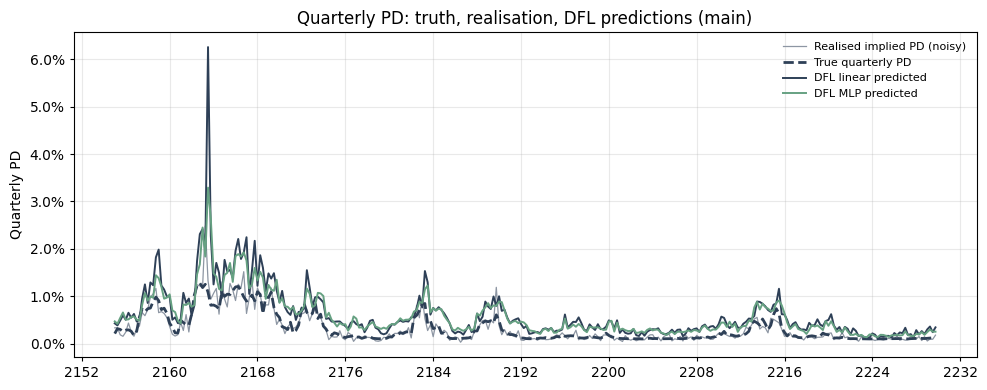

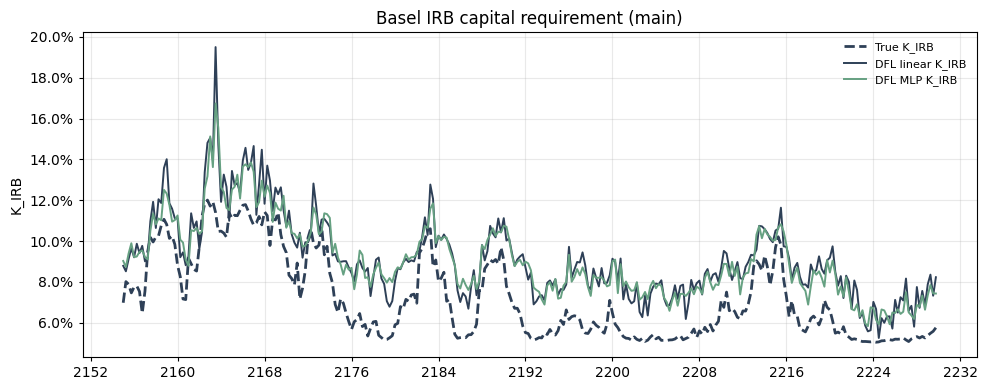

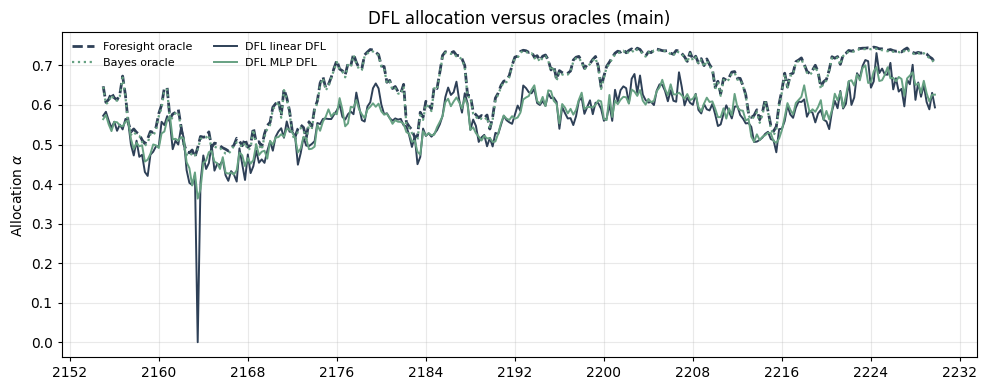

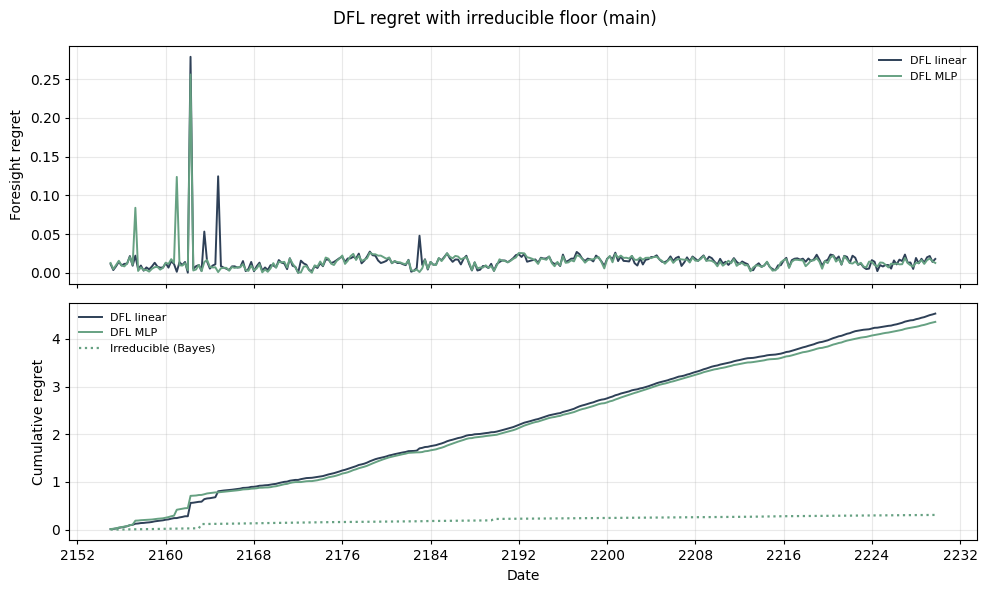

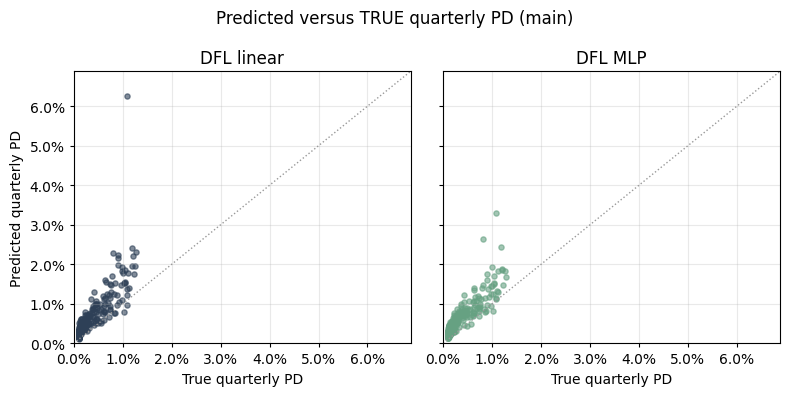

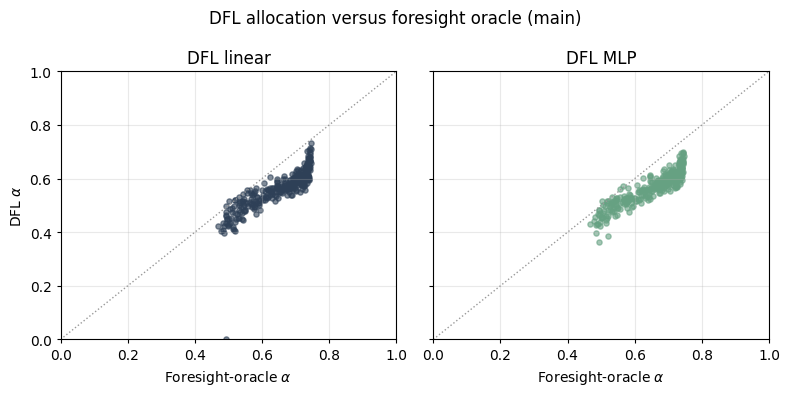

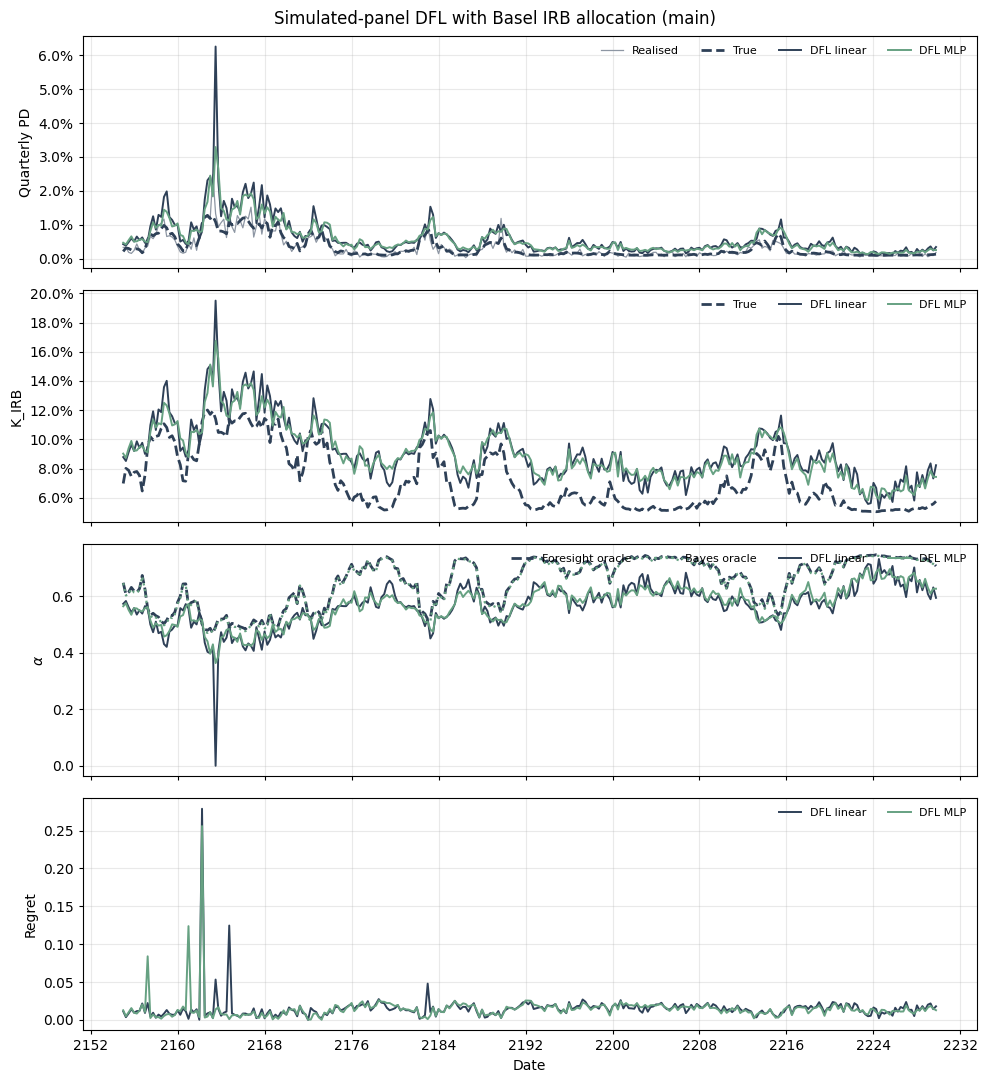

In [18]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"dfl_linear": MINOU_COLORS["navy"], "dfl_mlp": MINOU_COLORS["sage"]}
MODEL_LW = {"dfl_linear": 1.4, "dfl_mlp": 1.4}
MODEL_LABELS = {"dfl_linear": "DFL linear", "dfl_mlp": "DFL MLP"}
ORACLE_COLOR = MINOU_COLORS["navy"]
BAYES_COLOR = MINOU_COLORS["sage"]
TRUE_COLOR = MINOU_COLORS["navy"]
REALISED_COLOR = MINOU_COLORS["grey"]

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix=""):
    for m in MODEL_ORDER:
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()

    # 1. Quarterly PD: truth, noisy realisation, DFL predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised implied PD (noisy)")
    ax.plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD: truth, realisation, DFL predictions ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. K_IRB: true vs DFL-implied
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Allocations: foresight oracle, Bayes oracle, DFL
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(ax, plot_df, "alpha_hat", " DFL")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"DFL allocation versus oracles ({split_name})")
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. Regret and cumulative regret, with the irreducible floor
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in MODEL_ORDER:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color=BAYES_COLOR, lw=1.6, ls=":",
                 label="Irreducible (Bayes)")
    axes[0].set_ylabel("Foresight regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, plot_df)
    fig.suptitle(f"DFL regret with irreducible floor ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Predicted vs TRUE PD scatter
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_true"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in MODEL_ORDER)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), MODEL_ORDER):
        ax.scatter(plot_df["pd_q_true"], plot_df[f"pd_q_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
        ax.plot(lims, lims, color="#999999", lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("True quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle(f"Predicted versus TRUE quarterly PD ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_true_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. DFL alpha vs foresight-oracle alpha scatter
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharex=True, sharey=True)
    for ax, m in zip(np.atleast_1d(axes), MODEL_ORDER):
        ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
        ax.plot([0, 1], [0, 1], color="#999999", lw=1, ls=":")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel(r"DFL $\alpha$")
    fig.suptitle(f"DFL allocation versus foresight oracle ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REALISED_COLOR, lw=0.9, label="Realised")
    axes[0].plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["k_irb_true"], color=TRUE_COLOR, lw=2, ls="--", label="True")
    _model_lines(axes[1], plot_df, "k_irb_hat")
    axes[1].set_ylabel("K_IRB"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    axes[2].plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in MODEL_ORDER:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, plot_df); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Simulated-panel DFL with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_sim_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)


## Learning curves

Averaged across refits within each split; the MLP curve is the first ensemble seed only.
Early-stopped refits are padded by carrying the last value forward so the per-epoch mean
keeps constant composition. DFL gets two panels: validation PD RMSE (a free diagnostic -
DFL produces a PD every epoch even though it is not trained to minimise PD error) and
validation REGRET, its actual early-stopping criterion.


In [ ]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_rmse_pd_q", "val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean")))

        fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name)
            axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=label)
            axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        axes[0].set_ylabel("Val RMSE PD_Q (free diagnostic)")
        axes[1].set_ylabel("Val regret (early-stopping criterion)"); axes[1].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()
